# Hluti 1

## Prufukeyrsla

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags, csr_matrix
from Gemini_part1 import heatwave2, solve_ua, PoissonEq3, plot_comparison_table, theoretical_energy, compute_energy, energychange_theoretical, compute_energychange

In [2]:
L = 1
T = 1/20
N = 6
M = 4

def f(x):
    return np.ones_like(x) * 100

def psi(t):
    return np.zeros_like(t)

def phi(t):
    return np.zeros_like(t)

In [3]:
print(heatwave2(L, T, N, M, psi, phi, f))

Sigma: 0.45000000000000007
[[100.     100.     100.     100.     100.     100.     100.    ]
 [  0.     100.     100.     100.     100.     100.       0.    ]
 [  0.      55.     100.     100.     100.      55.       0.    ]
 [  0.      50.5     79.75   100.      79.75    50.5      0.    ]
 [  0.      40.9375  75.7     81.775   75.7     40.9375   0.    ]]


## Bein Lausn

In [4]:
def f_0(x):
    return 1 - np.abs(x- 1)

L_0 = 2
T_0 = 1
N_0 = 10
M_0 = 100

hw = heatwave2(L_0,T_0,N_0,M_0,psi,phi,f_0)

Sigma: 0.24999999999999994


In [5]:
print("HW:", hw[-1,:])

HW: [0.         0.02119985 0.04032452 0.05550194 0.06524644 0.06860417
 0.06524644 0.05550194 0.04032452 0.02119985 0.        ]


In [6]:
sol = []
for j in range(M_0+1):
    for i in range(N_0+1):    
        sol.append(solve_ua(L_0/(N_0)*i,T_0/(M_0)*j ,2))

ua = np.array(sol).reshape(M_0+1,N_0+1)

In [7]:
print("UA:", ua[-1,:])

UA: [0.00000000e+00 2.12419275e-02 4.04045472e-02 5.56120883e-02
 6.53759307e-02 6.87403215e-02 6.53759307e-02 5.56120883e-02
 4.04045472e-02 2.12419275e-02 8.41826146e-18]


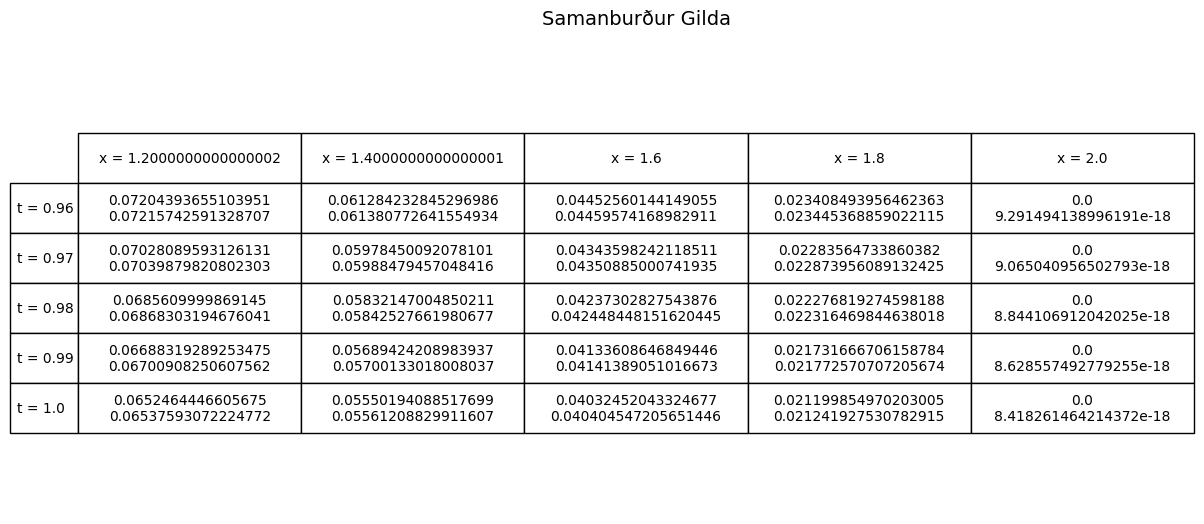

In [8]:
x_vals = [f"x = {v}" for v in np.linspace(0, L_0, N_0+1)[-5:]]
t_vals = [f"t = {v}" for v in np.linspace(0, T_0, M_0+1)[-5:]]


plot_comparison_table(hw[-5:,-5:], ua[-5:,-5:], x_vals, t_vals, title="Samanburður Gilda")

## Orka

### Orka sem fall af tíma

In [9]:
t = np.linspace(0,1,101)

E_comp = compute_energy(hw, 1/5)
print(E_comp[:5])

[0.34       0.321      0.304375   0.28902344 0.27466309]


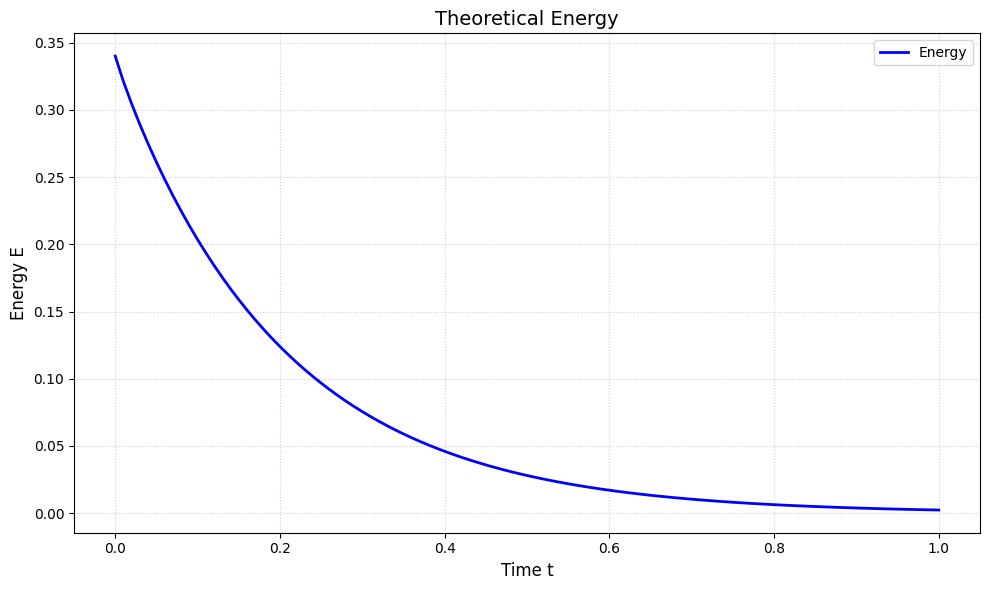

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(t, E_comp, label='Energy', color='blue', linewidth=2)

plt.title('Theoretical Energy', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('Energy E', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()

In [11]:
E_theor = []
for i in range(101):
    E_theor.append(theoretical_energy(1/101 * i,2))

print(E_theor[:5])

[np.float64(0.3333333264896874), np.float64(0.3156275242547669), np.float64(0.299658240189667), np.float64(0.28481941737785604), np.float64(0.2708947811246647)]


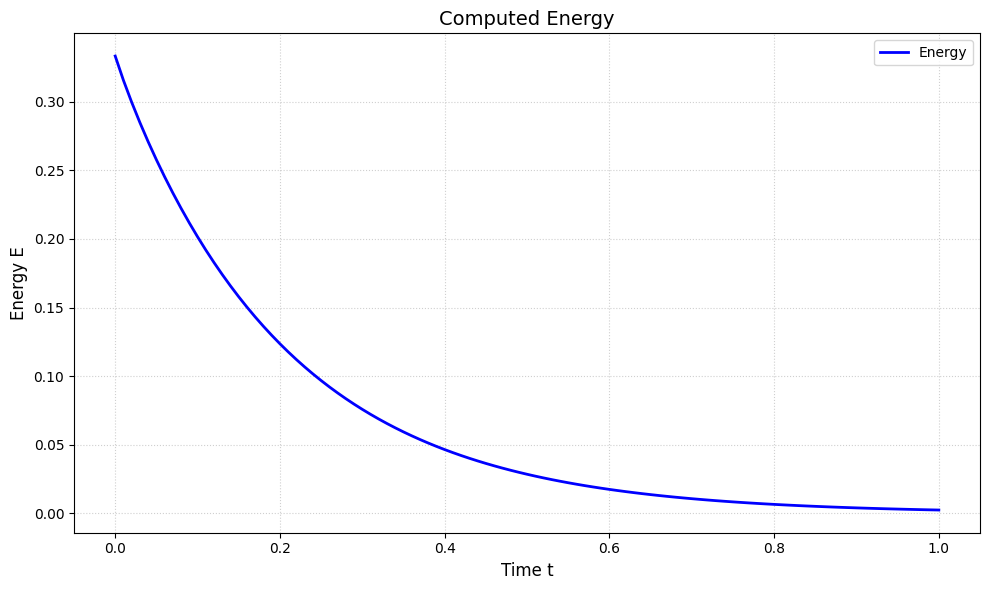

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(t, E_theor, label='Energy', color='blue', linewidth=2)

plt.title('Computed Energy', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('Energy E', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()

### Breyting á Orku m.t.t tíma

In [18]:
t2 = np.linspace(1/100,1,100)

dE_theor = energychange_theoretical(E_theor, 1/100)

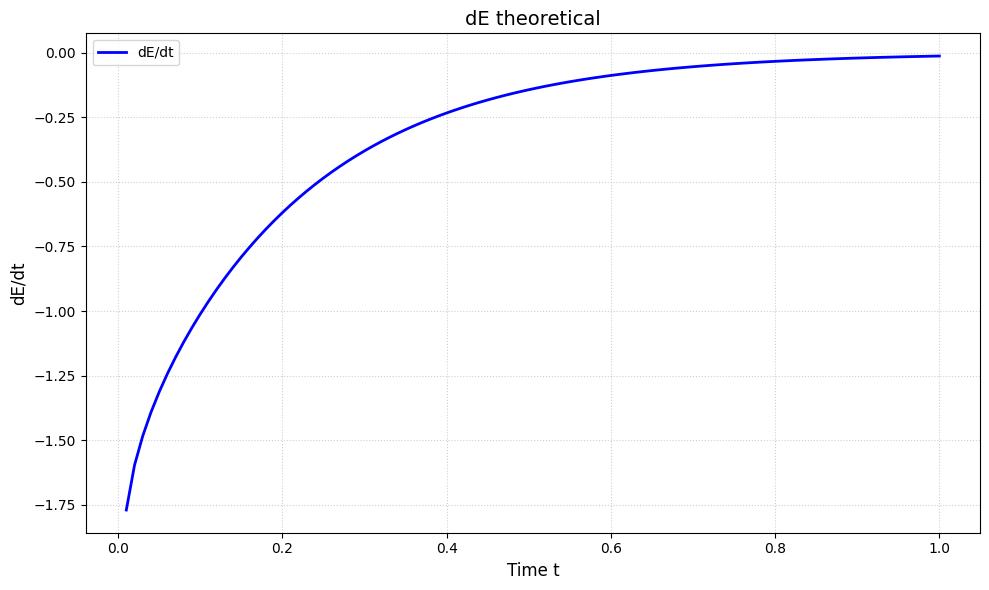

[np.float64(-1.7705802234920465), np.float64(-1.5969284065099898), np.float64(-1.483882281181098), np.float64(-1.3924636253191347), np.float64(-1.3135452680258897)]


In [19]:
plt.figure(figsize=(10, 6))

plt.plot(t2, dE_theor, label='dE/dt', color='blue', linewidth=2)

plt.title('dE theoretical', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('dE/dt', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()

print(dE_theor[:5])

In [15]:
dE_comp = compute_energychange(hw,1/5)
print(dE_comp.shape)

(101,)


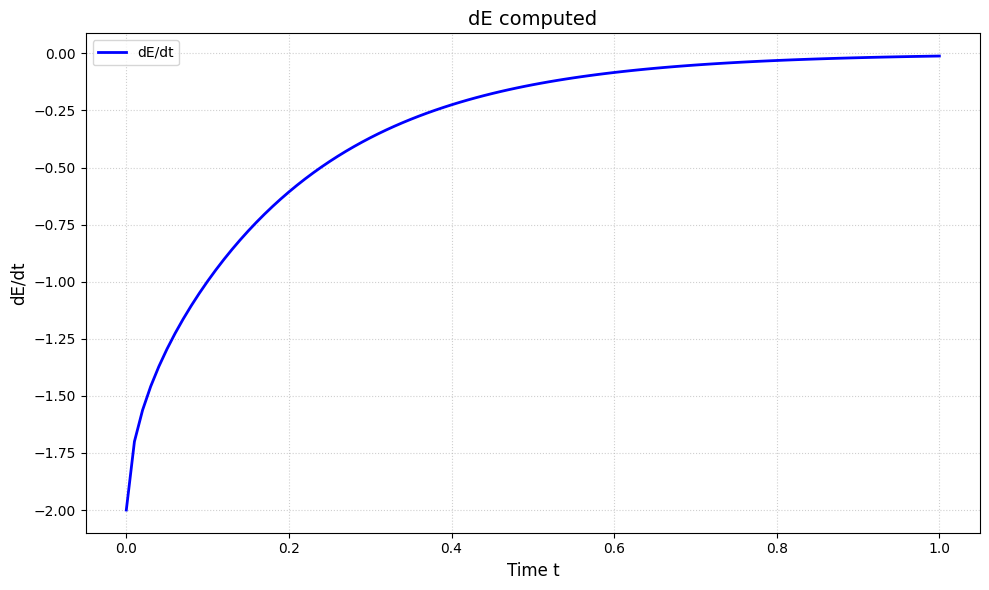

[-2.         -1.7        -1.5625     -1.45859375 -1.37158203]


In [16]:
plt.figure(figsize=(10, 6))

plt.plot(t, dE_comp, label='dE/dt', color='blue', linewidth=2)

plt.title('dE computed', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('dE/dt', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()

print(dE_comp[:5])

## Hliðruð Jaðarskilyrði

In [35]:
def psi2(t):
    return 1 + 1/2 *np.sin(2*np.pi*t)

def phi2(t):
    return 1 - 1/2 * np.cos(2*np.pi*t)

N2 = 20
M2 = 200

In [36]:
hw2 = heatwave2(L_0, T_0, N2, M2, psi2, phi2, f_0)
t2 = np.linspace(0,1,201)

dE_comp2 = compute_energychange(hw2,1/10)

Sigma: 0.4999999999999999


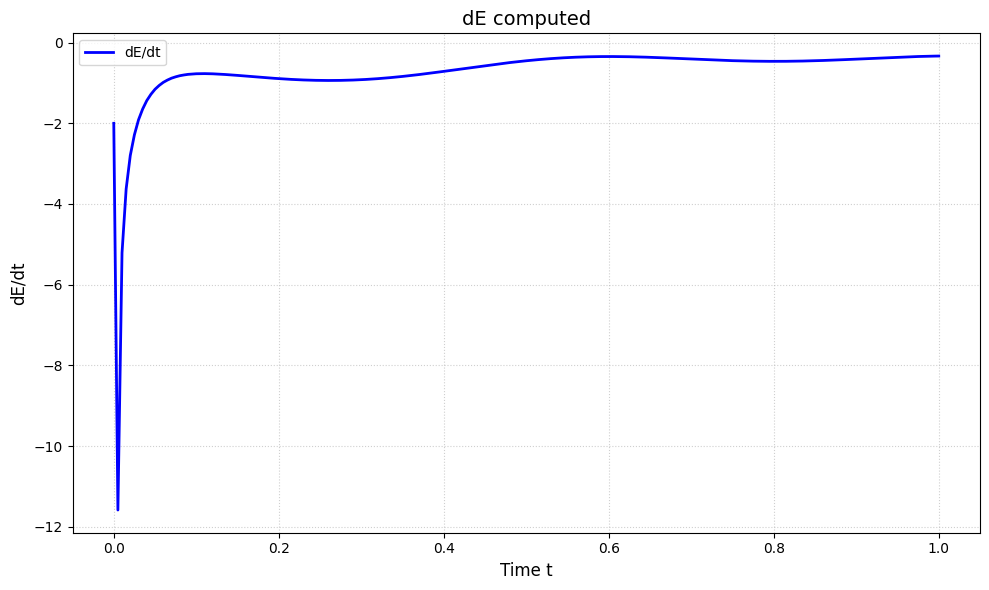

[ -2.         -11.58713779  -5.21028876  -3.62727265  -2.79786027]


In [37]:
plt.figure(figsize=(10, 6))

plt.plot(t2, dE_comp2, label='dE/dt', color='blue', linewidth=2)

plt.title('dE computed', fontsize=14)
plt.xlabel('Time t', fontsize=12)
plt.ylabel('dE/dt', fontsize=12)

# Grid: 'alpha' controls transparency, 'linestyle' makes it less distracting
plt.grid(True, linestyle=':', alpha=0.6)

# Legend: automatically uses the 'label' arguments from plt.plot()
plt.legend(loc='best', frameon=True)

# 4. Show/Save
plt.tight_layout() # Adjusts spacing so labels don't get cut off
plt.show()

print(dE_comp2[:5])

# Hluti 2

## Prufukeyrsla

In [46]:
L1 = 1
L2 = 1
h = 1/5
k = 1/4

def ub(x):
    return np.ones_like(x)

def ut(x):
    return np.ones_like(x)*2

def vl(y):
    return np.ones_like(y)*3

def vr(y):
    return np.ones_like(y)*4

def f(x, y):
    return x

In [73]:
print(PoissonEq3(L1, L2, h, k, ub, ut, vl, vr, f))

[[1.         1.         1.         1.         1.         1.        ]
 [3.         2.23912343 2.02541792 2.15980541 2.69821089 4.        ]
 [3.         2.6107921  2.48194051 2.65083273 3.15363484 4.        ]
 [3.         2.56315406 2.44823837 2.58262586 3.02224151 4.        ]
 [2.         2.         2.         2.         2.         2.        ]]


## Bein Lausn

In [47]:
def ut2(x):
    return np.exp(-L2*x)

def vl2(y):
    return np.ones_like(x)

def vr2(y):
    return np.exp(-L2*y)

def f2(x,y):
    return -np.exp(-x*y)*(x**2+y**2)

h2 = 1/10
k2 = 1/15

In [48]:
print(PoissonEq3(L1,L2,h2,k2,ub,ut2,vl2,vr2,f2))

NameError: name 'x' is not defined